In [1]:
from keras.layers import *
from keras.models import Model

In [2]:
# define two sets of inputs
inputA = Input(shape=(32,))
inputB = Input(shape=(128,))

In [3]:
# the first branch operates on the first input
x = Dense(8, activation="relu")(inputA)
x1 = Dense(4, activation="relu")(x)

2025-08-25 20:11:21.204031: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-08-25 20:11:21.204057: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-08-25 20:11:21.204064: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-08-25 20:11:21.204080: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-25 20:11:21.204091: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
# the second branch opreates on the second input
y = Dense(64, activation="relu")(inputB)
y1 = Dense(32, activation="relu")(y)
y2 = Dense(4, activation="relu")(y1)

In [5]:
# combine the output of the two branches
combined = concatenate([x1, y2])

In [6]:
# apply a FC layer and then a regression prediction on the
# combined outputs
z = Dense(2, activation="relu")(combined)
z1 = Dense(1, activation="linear")(z)

In [7]:
# our model will accept the inputs of the two branches and
# then output a single value
model = Model(inputs=[inputA, inputB], outputs=z1)

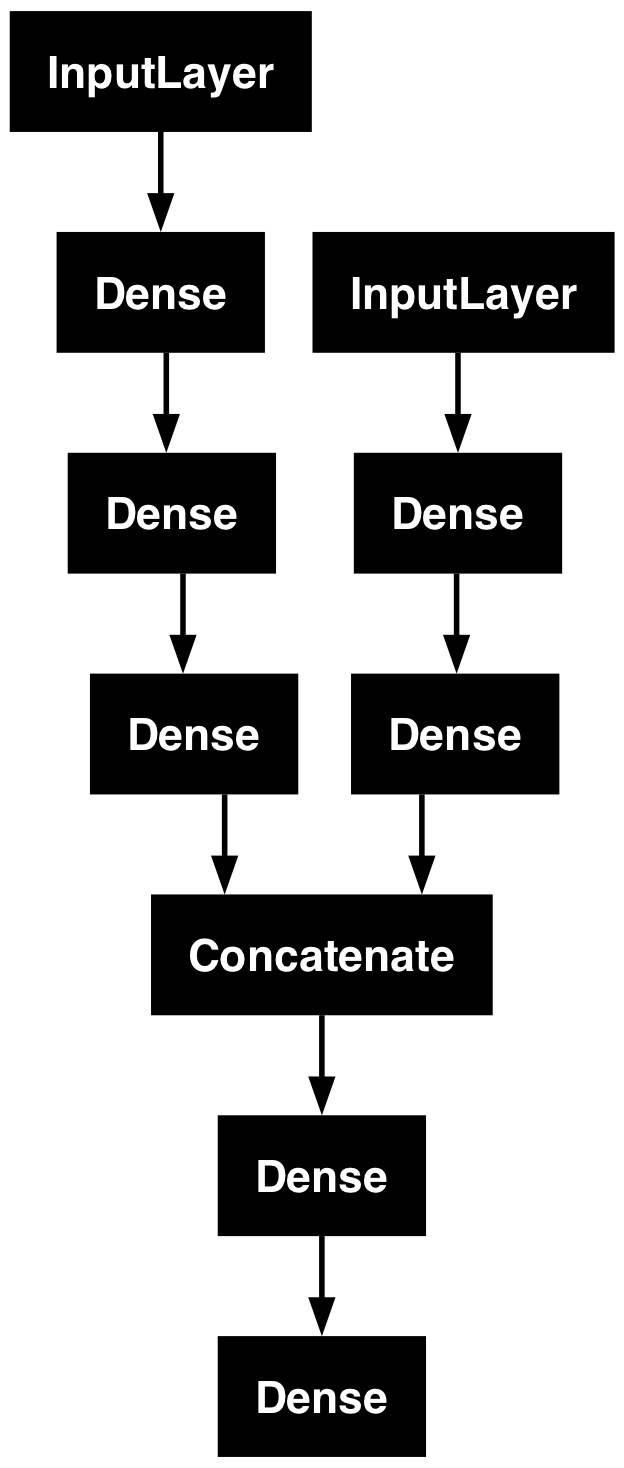

In [8]:
from keras.utils import plot_model
plot_model(model)